#Comparison, Threshold & Final Evaluation


1. Assembles the comparison table across all models plus both baselines
2. Tests whether the differences are statistically real (they probably aren't)
3. Tunes a decision threshold against an explicit cost matrix
4. Evaluates **one** selected model on the sealed test set, **once**



In [1]:
import os, sys, shutil
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!pip install statsmodels -q

FOLDER = "/content/drive/MyDrive/GrainWise_Project_ML"

if not os.path.isdir(FOLDER):
    print("Folder not found:", FOLDER)
    print("\nFolders in your MyDrive:")
    for d in sorted(os.listdir("/content/drive/MyDrive")):
        print("   ", d)
    raise SystemExit("Fix FOLDER above, then re-run this cell.")

print("Files in that folder:", os.listdir(FOLDER))

shutil.copy(f"{FOLDER}/rice_shared.py", "/content/rice_shared.py")
sys.path.insert(0, "/content")

import numpy as np, pandas as pd, glob, matplotlib.pyplot as plt, seaborn as sns
import rice_shared as rs
sns.set_theme(style="whitegrid")

rs.DATA_PATH = f"{FOLDER}/Rice_Cammeo_Osmancik.arff"
X_train, X_test, y_train, y_test = rs.get_split("all")

print("\nTrain:", X_train.shape, " Test:", X_test.shape)
print("Train balance:", round(y_train.mean(), 4))
print("\nMUST read (3048, 10) and 0.4278.")

Files in that folder: ['Citation_Request.txt', 'Rice_Cammeo_Osmancik.arff', 'rice_shared.py']

Train: (3048, 10)  Test: (762, 10)
Train balance: 0.4278

MUST read (3048, 10) and 0.4278.


## 1 — Assemble the comparison table



In [3]:
RESULTS_DIR = "/content/drive/MyDrive/AllModels_Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

csvs  = sorted(glob.glob(f"{RESULTS_DIR}/results_*.csv"))  or sorted(glob.glob("results_*.csv"))
folds = sorted(glob.glob(f"{RESULTS_DIR}/*_folds.npy"))    or sorted(glob.glob("*_folds.npy"))

print("CSV files :", [p.split("/")[-1] for p in csvs])
print("Fold files:", [p.split("/")[-1] for p in folds])

if len(csvs) < 4:
    print(f"\n!! Only {len(csvs)} of 4 results files found.")
    print("   Collect results_logreg / results_rf / results_svm / results_knn")
    print("   (.csv AND _folds.npy for each) into", RESULTS_DIR)
if len(folds) < len(csvs):
    print("\n!! Missing _folds.npy files - the paired statistical tests need these.")
assert csvs, "No results_*.csv found anywhere."

comp = pd.concat([pd.read_csv(p) for p in csvs], ignore_index=True)
cols = ["model", "accuracy_mean", "accuracy_std", "precision_mean",
        "recall_mean", "f1_mean", "roc_auc_mean", "fit_time_s"]
comp = comp[[c for c in cols if c in comp.columns]].sort_values(
    "accuracy_mean", ascending=False).reset_index(drop=True)
display(comp.round(4))

CSV files : ['results_knn.csv', 'results_logreg.csv', 'results_rf.csv', 'results_svm.csv']
Fold files: ['results_knn_folds.npy', 'results_logreg_folds.npy', 'results_rf_folds.npy', 'results_svm_folds.npy']


,model,accuracy_mean,accuracy_std,precision_mean,recall_mean,f1_mean,roc_auc_mean,fit_time_s
0,Logistic Regression,0.9307,0.0117,0.9246,0.9131,0.9185,0.9799,0.0169
1,Support Vector Machine,0.9281,0.0110,0.9223,0.9093,0.9155,0.9799,0.9698
2,k-Nearest Neighbours,0.9280,0.0117,0.9154,0.9169,0.9159,0.9759,0.0220
3,Random Forest,0.9274,0.0113,0.9190,0.9110,0.9148,0.9782,3.2249


### Add the baselines
A comparison without the floor is not a comparison. These are recomputed here so the
table is self-contained.

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier

base_rows = []
for nm, mdl in [("BASELINE: majority class", DummyClassifier(strategy="most_frequent")),
                ("BASELINE: 1-feature threshold",
                 DecisionTreeClassifier(max_depth=1, random_state=rs.RANDOM_STATE))]:
    r, res = rs.score(mdl, X_train, y_train, name=nm, scale=False)
    base_rows.append(r)
    np.save(f"folds_{nm.split(':')[1].strip().replace(' ','_')}.npy", res["test_accuracy"])

full = pd.concat([pd.DataFrame(base_rows), comp], ignore_index=True)
full = full[[c for c in cols if c in full.columns]].sort_values(
    "accuracy_mean", ascending=False).reset_index(drop=True)
display(full.round(4))

best_model_acc = full.loc[~full.model.str.startswith("BASELINE"), "accuracy_mean"].max()
stump_acc = full.loc[full.model.str.contains("1-feature"), "accuracy_mean"].iloc[0]
print(f"\nBest model:        {best_model_acc:.4f}")
print(f"1-feature baseline: {stump_acc:.4f}")
print(f"GAP:                {100*(best_model_acc - stump_acc):.2f} percentage points")

,model,accuracy_mean,accuracy_std,precision_mean,recall_mean,f1_mean,roc_auc_mean,fit_time_s
0,Logistic Regression,0.9307,0.0117,0.9246,0.9131,0.9185,0.9799,0.0169
1,BASELINE: 1-feature threshold,0.9290,0.0137,0.9199,0.9144,0.9168,0.9272,0.0126
2,Support Vector Machine,0.9281,0.0110,0.9223,0.9093,0.9155,0.9799,0.9698
3,k-Nearest Neighbours,0.9280,0.0117,0.9154,0.9169,0.9159,0.9759,0.0220
4,Random Forest,0.9274,0.0113,0.9190,0.9110,0.9148,0.9782,3.2249
5,BASELINE: majority class,0.5722,0.0015,0.0000,0.0000,0.0000,0.5000,0.0030



Best model:        0.9307
1-feature baseline: 0.9290
GAP:                0.16 percentage points


## 2 — Are the differences real?
With every model inside ~1 point, a ranking is meaningless without a significance test.

**Corrected paired t-test (Nadeau & Bengio).** A plain paired t-test across CV folds
is anti-conservative because the folds share training data. The correction inflates the
variance by `1/k + test_ratio/train_ratio`. Using the uncorrected test here would be
exactly the kind of overclaiming the rubric penalises.

In [5]:
from scipy import stats

def corrected_t(a, b, n_splits=10, n_repeats=3):
    """Nadeau-Bengio corrected paired t-test for repeated k-fold CV."""
    d = np.asarray(a) - np.asarray(b)
    n = len(d)
    test_ratio = 1.0 / n_splits
    corrected_var = d.var(ddof=1) * (1.0 / n + test_ratio / (1 - test_ratio))
    if corrected_var <= 0:
        return 0.0, 1.0
    t = d.mean() / np.sqrt(corrected_var)
    p = 2 * (1 - stats.t.cdf(abs(t), df=n - 1))
    return float(t), float(p)

def load_folds():
    """Collect per-fold accuracy arrays, de-duplicated by model name."""
    found = {}
    for pat in ["folds_*.npy", "*_folds.npy",
                f"{RESULTS_DIR}/folds_*.npy", f"{RESULTS_DIR}/*_folds.npy"]:
        for p in glob.glob(pat):
            stem = p.split("/")[-1]
            if stem.startswith("folds_"):
                name = stem[len("folds_"):-len(".npy")]
            else:
                name = stem[:-len("_folds.npy")].replace("results_", "")
            found.setdefault(name.replace("_", " "), p)   # first match wins
    return {k: np.load(v) for k, v in found.items()}

folds = load_folds()
lens = {k: len(v) for k, v in folds.items()}
print("Fold arrays loaded:", lens)

sizes = set(lens.values())
if len(sizes) > 1:
    keep = max(sizes, key=lambda n: sum(1 for v in lens.values() if v == n))
    dropped = [k for k, n in lens.items() if n != keep]
    print(f"\n!! Fold-count mismatch. Keeping the {keep}-fold group; excluded: {dropped}")
    print("   Those members did not use rs.CV - ask them to re-run with the default cv.")
    folds = {k: v for k, v in folds.items() if lens[k] == keep}

N_SPLITS = 10 if len(next(iter(folds.values()))) % 10 == 0 else 5
names = list(folds)
out = []
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        t, p = corrected_t(folds[names[i]], folds[names[j]], n_splits=N_SPLITS)
        out.append({"A": names[i], "B": names[j],
                    "mean_diff": folds[names[i]].mean() - folds[names[j]].mean(),
                    "t": t, "p_value": p,
                    "significant_0.05": "YES" if p < 0.05 else "no"})
pairs = pd.DataFrame(out).sort_values("p_value").reset_index(drop=True)
display(pairs.round(4))
print("\n'no' means the two models are statistically indistinguishable on this data.")

Fold arrays loaded: {'majority class': 30, '1-feature threshold': 30, 'logreg': 30, 'rf': 30, 'knn': 30, 'svm': 30}


,A,B,mean_diff,t,p_value,significant_0.05
0,majority class,1-feature threshold,-0.3568,-67.5002,0.0000,YES
1,majority class,logreg,-0.3585,-80.5235,0.0000,YES
2,majority class,rf,-0.3552,-82.6248,0.0000,YES
3,majority class,knn,-0.3559,-78.4969,0.0000,YES
4,majority class,svm,-0.3560,-85.5633,0.0000,YES
5,logreg,svm,0.0025,1.0776,0.2901,no
6,logreg,rf,0.0033,0.9862,0.3322,no
7,logreg,knn,0.0026,0.8992,0.3760,no
8,1-feature threshold,rf,0.0016,0.4847,0.6315,no
9,1-feature threshold,logreg,-0.0016,-0.3794,0.7072,no



'no' means the two models are statistically indistinguishable on this data.


### McNemar's test on the strongest pair
The t-test compares fold means. McNemar compares *which individual grains* each model
got wrong — a stricter, paired-by-sample test. Predictions come from `cross_val_predict`
on the training set, so the sealed test set stays untouched.

In [6]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.contingency_tables import mcnemar

cvp = StratifiedKFold(n_splits=10, shuffle=True, random_state=rs.RANDOM_STATE)
pred_lr = cross_val_predict(rs.make_pipeline(LogisticRegression(max_iter=5000), scale=True),
                            X_train, y_train, cv=cvp, n_jobs=-1)
pred_st = cross_val_predict(rs.make_pipeline(
                                DecisionTreeClassifier(max_depth=1,
                                                       random_state=rs.RANDOM_STATE),
                                scale=False),
                            X_train, y_train, cv=cvp, n_jobs=-1)

tb = np.array([[int(((pred_lr == y_train) & (pred_st == y_train)).sum()),
                int(((pred_lr == y_train) & (pred_st != y_train)).sum())],
               [int(((pred_lr != y_train) & (pred_st == y_train)).sum()),
                int(((pred_lr != y_train) & (pred_st != y_train)).sum())]])
print("Contingency (rows = LogReg correct/wrong, cols = stump correct/wrong):")
print(tb)
r = mcnemar(tb, exact=False, correction=True)
print(f"\nMcNemar chi2 = {r.statistic:.4f}, p = {r.pvalue:.4f}")
print("LogReg right / stump wrong:", tb[0, 1], " | stump right / LogReg wrong:", tb[1, 0])
print("\np > 0.05 => the full model does not beat one threshold at a detectable level.")

Contingency (rows = LogReg correct/wrong, cols = stump correct/wrong):
[[2811   27]
 [  25  185]]

McNemar chi2 = 0.0192, p = 0.8897
LogReg right / stump wrong: 27  | stump right / LogReg wrong: 25

p > 0.05 => the full model does not beat one threshold at a detectable level.


## 3 — Cost-sensitive threshold
Accuracy weights both errors equally. The mill does not.

**Cost assumption (state this as an assumption in the report — we have no stakeholder
figures):** calling an Osmancik grain "Cammeo" means paying a premium price for standard
rice and blending it into a branded batch — an authenticity and pricing failure. Calling
a Cammeo grain "Osmancik" is lost margin. We weight the first error **5×** the second.

Everything here uses cross-validated predictions on the training set.

Cost-minimising threshold: 0.805  (default 0.5)
Expected cost at 0.805: 420   at 0.500: 590


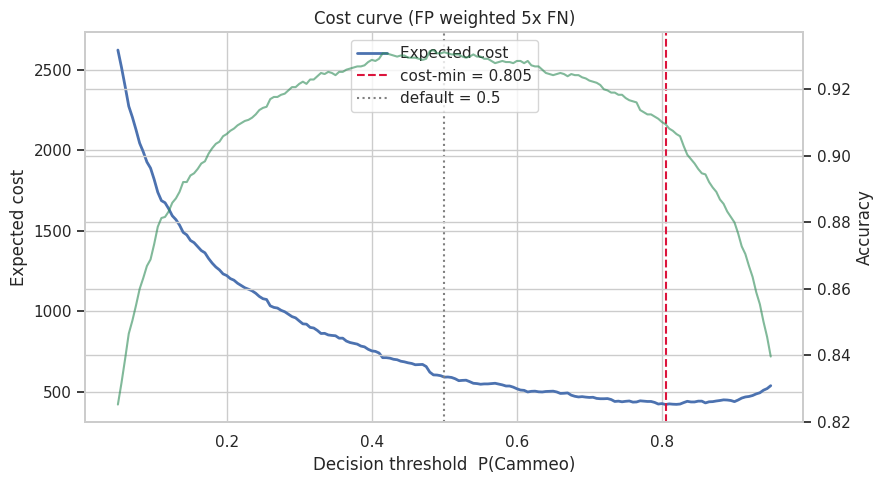

In [7]:
from sklearn.metrics import confusion_matrix, precision_recall_curve

COST_FP = 5.0   # Osmancik predicted Cammeo - overpayment / adulterated premium batch
COST_FN = 1.0   # Cammeo predicted Osmancik - lost margin

proba = cross_val_predict(rs.make_pipeline(LogisticRegression(max_iter=5000), scale=True),
                          X_train, y_train, cv=cvp, method="predict_proba", n_jobs=-1)[:, 1]

ths = np.linspace(0.05, 0.95, 181)
costs, accs = [], []
for t in ths:
    tn, fp, fn, tp = confusion_matrix(y_train, (proba >= t).astype(int)).ravel()
    costs.append(fp * COST_FP + fn * COST_FN)
    accs.append((tp + tn) / len(y_train))

best_t = float(ths[int(np.argmin(costs))])
print(f"Cost-minimising threshold: {best_t:.3f}  (default 0.5)")
print(f"Expected cost at {best_t:.3f}: {min(costs):,.0f}   at 0.500: "
      f"{costs[int(np.argmin(np.abs(ths-0.5)))]:,.0f}")

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(ths, costs, lw=2, label="Expected cost")
ax1.axvline(best_t, ls="--", color="crimson", label=f"cost-min = {best_t:.3f}")
ax1.axvline(0.5, ls=":", color="grey", label="default = 0.5")
ax1.set_xlabel("Decision threshold  P(Cammeo)"); ax1.set_ylabel("Expected cost")
ax2 = ax1.twinx(); ax2.plot(ths, accs, color="seagreen", alpha=.6, label="Accuracy")
ax2.set_ylabel("Accuracy"); ax1.legend(loc="upper center")
plt.title(f"Cost curve (FP weighted {COST_FP:g}x FN)"); plt.tight_layout(); plt.show()

## 4 —  FINAL TEST EVALUATION


=== FINAL TEST RESULT (threshold 0.805) ===
              precision    recall  f1-score   support

    Osmancik     0.8745    0.9748    0.9219       436
      Cammeo     0.9601    0.8129    0.8804       326

    accuracy                         0.9055       762
   macro avg     0.9173    0.8938    0.9012       762
weighted avg     0.9111    0.9055    0.9041       762

ROC-AUC: 0.978

FP (Osmancik sold as Cammeo): 11   FN (Cammeo sold as Osmancik): 61
Expected cost on test set: 116


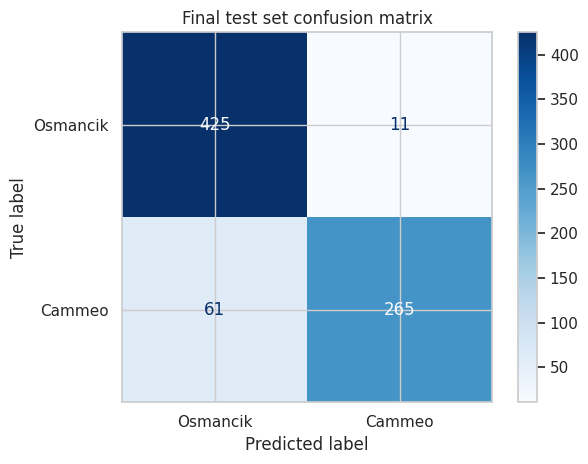

In [8]:
FINAL_MODEL = LogisticRegression(max_iter=5000, C=3.1622776601683795,
                                 penalty="l2", solver="liblinear")
FINAL_SCALE = True
FINAL_THRESHOLD = best_t

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

final = rs.make_pipeline(FINAL_MODEL, scale=FINAL_SCALE).fit(X_train, y_train)
p_test = final.predict_proba(X_test)[:, 1]
y_pred = (p_test >= FINAL_THRESHOLD).astype(int)

print(f"=== FINAL TEST RESULT (threshold {FINAL_THRESHOLD:.3f}) ===")
print(classification_report(y_test, y_pred, target_names=["Osmancik", "Cammeo"], digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, p_test), 4))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"\nFP (Osmancik sold as Cammeo): {fp}   FN (Cammeo sold as Osmancik): {fn}")
print(f"Expected cost on test set: {fp*COST_FP + fn*COST_FN:,.0f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Osmancik", "Cammeo"], cmap="Blues")
plt.title("Final test set confusion matrix"); plt.tight_layout(); plt.show()

Brier score: 0.0527   (no-skill baseline: 0.2448)
Brier skill score: 0.7848   (1.0 = perfect, 0 = no better than guessing)
Max calibration gap: 0.0246
Mean calibration gap: 0.0063

 predicted P(Cammeo)  actual fraction Cammeo     gap
              0.0007                  0.0000 -0.0007
              0.0033                  0.0033  0.0000
              0.0096                  0.0098  0.0002
              0.0285                  0.0230 -0.0055
              0.0902                  0.1148  0.0246
              0.3746                  0.3541 -0.0205
              0.8180                  0.8224  0.0044
              0.9618                  0.9574 -0.0045
              0.9924                  0.9934  0.0010
              0.9989                  1.0000  0.0011


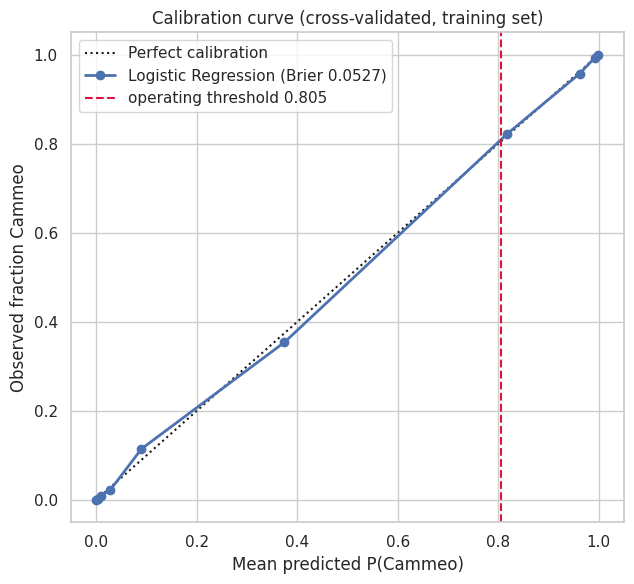


At the bin closest to the 0.805 operating point:
  model predicts 0.818, observed rate is 0.822


In [11]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

frac_pos, mean_pred = calibration_curve(y_train, proba, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_train, proba)
baseline_brier = brier_score_loss(y_train, np.full_like(proba, y_train.mean()))

print(f"Brier score: {brier:.4f}   (no-skill baseline: {baseline_brier:.4f})")
print(f"Brier skill score: {1 - brier/baseline_brier:.4f}   (1.0 = perfect, 0 = no better than guessing)")
print(f"Max calibration gap: {np.abs(frac_pos - mean_pred).max():.4f}")
print(f"Mean calibration gap: {np.abs(frac_pos - mean_pred).mean():.4f}\n")

print(pd.DataFrame({"predicted P(Cammeo)": mean_pred,
                    "actual fraction Cammeo": frac_pos,
                    "gap": frac_pos - mean_pred}).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], "k:", label="Perfect calibration")
ax.plot(mean_pred, frac_pos, "o-", lw=2, label=f"Logistic Regression (Brier {brier:.4f})")
ax.axvline(best_t, ls="--", color="crimson", label=f"operating threshold {best_t:.3f}")
ax.set_xlabel("Mean predicted P(Cammeo)"); ax.set_ylabel("Observed fraction Cammeo")
ax.set_title("Calibration curve (cross-validated, training set)")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

near = np.abs(mean_pred - best_t).argmin()
print(f"\nAt the bin closest to the {best_t:.3f} operating point:")
print(f"  model predicts {mean_pred[near]:.3f}, observed rate is {frac_pos[near]:.3f}")

### The same test, for the one-threshold baseline
If the gap on held-out data is as small as cross-validation suggested, the
recommendation writes itself.

In [9]:
stump_final = DecisionTreeClassifier(max_depth=1, random_state=rs.RANDOM_STATE)
stump_final.fit(X_train, y_train)
y_stump = stump_final.predict(X_test)
tn2, fp2, fn2, tp2 = confusion_matrix(y_test, y_stump).ravel()

# the full model at its DEFAULT threshold, for a like-for-like accuracy comparison
y_def = (p_test >= 0.5).astype(int)
tn3, fp3, fn3, tp3 = confusion_matrix(y_test, y_def).ravel()

rows = [
    {"system": "1-threshold baseline", "threshold": "n/a",
     "accuracy": (tp2 + tn2) / len(y_test), "FP": fp2, "FN": fn2,
     "cost": fp2 * COST_FP + fn2 * COST_FN},
    {"system": "Full model", "threshold": "0.500 (default)",
     "accuracy": (tp3 + tn3) / len(y_test), "FP": fp3, "FN": fn3,
     "cost": fp3 * COST_FP + fn3 * COST_FN},
    {"system": "Full model", "threshold": f"{FINAL_THRESHOLD:.3f} (cost-tuned)",
     "accuracy": (tp + tn) / len(y_test), "FP": fp, "FN": fn,
     "cost": fp * COST_FP + fn * COST_FN},
]
display(pd.DataFrame(rows).round(4))

print("Read this table on TWO axes, not one:")
print(" - Accuracy: compare the baseline against the full model at its DEFAULT 0.5.")
print("   Comparing against the cost-tuned row is apples-to-oranges - tuning")
print("   deliberately trades accuracy away to avoid the expensive error.")
print(f" - Cost: the tuned threshold is the operating point the {COST_FP:g}:1 assumption implies.")
print("\nIf the accuracy gap at 0.5 is under ~1 point, say plainly in the report that")
print("the full model does not earn its complexity on accuracy alone, and that its")
print("real value is the tunable probability output - which one fixed threshold cannot give.")

,system,threshold,accuracy,FP,FN,cost
0,1-threshold baseline,n/a,0.9160,35,29,204.0
1,Full model,0.500 (default),0.9265,32,24,184.0
2,Full model,0.805 (cost-tuned),0.9055,11,61,116.0


Read this table on TWO axes, not one:
 - Accuracy: compare the baseline against the full model at its DEFAULT 0.5.
   Comparing against the cost-tuned row is apples-to-oranges - tuning
   deliberately trades accuracy away to avoid the expensive error.
 - Cost: the tuned threshold is the operating point the 5:1 assumption implies.

If the accuracy gap at 0.5 is under ~1 point, say plainly in the report that
the full model does not earn its complexity on accuracy alone, and that its
real value is the tunable probability output - which one fixed threshold cannot give.


### Sensitivity of the cost assumption


In [10]:
for ratio in [1, 2, 5, 10, 20]:
    c = [confusion_matrix(y_train, (proba >= t).astype(int)).ravel() for t in ths]
    costs_r = [fp_ * ratio + fn_ * 1.0 for (tn_, fp_, fn_, tp_) in c]
    t_star = ths[int(np.argmin(costs_r))]
    print(f"FP:FN = {ratio:2d}:1  ->  optimal threshold {t_star:.3f}")
print("\nReport the range, not just the 5:1 answer. A recommendation that holds across")
print("plausible cost ratios is far stronger than one tuned to a number we made up.")

FP:FN =  1:1  ->  optimal threshold 0.485
FP:FN =  2:1  ->  optimal threshold 0.615
FP:FN =  5:1  ->  optimal threshold 0.805
FP:FN = 10:1  ->  optimal threshold 0.900
FP:FN = 20:1  ->  optimal threshold 0.935

Report the range, not just the 5:1 answer. A recommendation that holds across
plausible cost ratios is far stronger than one tuned to a number we made up.
